<a href="https://colab.research.google.com/github/Sayak-coder/SIH_26086/blob/main/pricipitation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

In [2]:
!pip install --upgrade xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.5 MB/s eta 0:00:00


In [3]:
!pip install -u geemap


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -u


In [4]:
import ee

In [5]:
ee.Authenticate()
ee.Initialize(
    project='gen-lang-client-0960220624',
    opt_url='https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [6]:
import geemap

In [32]:
map=geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [106]:
roi=map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -273.35083,
                          22.177232
                        ],
                        [
                          -273.35083,
                          25.700938
                        ],
                        [
                          -271.164551,
                          25.700938
                        ],
                        [
                          -271.164551,
                          22.177232
                        ],
                        [
                          -273.35083,
                          22.177232
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [107]:
def wrap_lon(lon):
    return ((lon + 180) % 360) - 180

# Get the full geometry info to check its type and coordinates structure
roi_info = roi.getInfo()
geometry_type = roi_info['type']
coords = roi_info['coordinates']

if geometry_type == 'Point':
  # For a Point, coords is [lon, lat]
  lon = coords[0]
  lat = coords[1]
  fixed_coords = [wrap_lon(lon), lat]
  roi_fixed = ee.Geometry.Point(fixed_coords)
elif geometry_type == 'Polygon':
  # For a Polygon, coords is [[[lon, lat], ...], ...]
  fixed_coords = []
  for ring in coords: # Each ring is a list of [lon, lat] pairs
    fixed_ring = []
    for point in ring: # Each point is [lon, lat]
      fixed_ring.append([wrap_lon(point[0]), point[1]])
    fixed_coords.append(fixed_ring)
  roi_fixed = ee.Geometry.Polygon(fixed_coords)
else:
  # Handle other geometry types if necessary, or raise an error
  raise ValueError(f"Unsupported geometry type: {geometry_type}")

In [108]:
roi_fixed

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            [
              86.64917000000003,
              22.177232
            ],
            [
              86.64917000000003,
              25.700938
            ],
            [
              88.83544899999998,
              25.700938
            ],
            [
              88.83544899999998,
              22.177232
            ],
            [
              86.64917000000003,
              22.177232
            ]
          ]
        ]
      },
      "evenOdd": {
        "constantValue": true
      }
    }
  }
})

In [109]:
time_start=ee.Date('2015')
time_end=ee.Date('2025')
time_diff=time_end.difference(time_start,'month')

In [110]:

time_start = ee.Date('2002')
time_end  = ee.Date('2025')
time_dif = time_end.difference(time_start, 'month').round()
time_list = ee.List.sequence(0, ee.Number(time_dif).subtract(1)).map(
    lambda x: time_start.advance(x, 'month')
)

def monthly(date_list, col):
  start_date = ee.Date(date_list)
  end_date = start_date.advance(1, 'month')
  col_agg = col.filterDate(start_date, end_date).mean()
  return col_agg.set('system:time_start', start_date.millis())

pr = (
    ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07")
    .filterDate(time_start, time_end)
    .select(['precipitation'],['pr'])
)

veg = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate(time_start, time_end)
    .select(['NDVI','EVI'],['ndvi','evi'])
)

temp = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterDate(time_start, time_end)
    .select(['LST_Day_1km','LST_Night_1km'],['temp_day','temp_night'])
)

et = (
    ee.ImageCollection("MODIS/061/MOD16A2GF")
    .filterDate(time_start, time_end)
    .select(['ET'],['et'])
)

veg_monthly = ee.ImageCollection(
    time_list.map(
        lambda x: monthly(x, veg)
    ))

temp_months= ee.ImageCollection(
    time_list.map(
        lambda x: monthly(x,temp)
    )
)

et_monthly=ee.ImageCollection(
    time_list.map(
        lambda x: monthly(x, et)
    )
)

pr_monthly=ee.ImageCollection(
    time_list.map(
        lambda x:monthly(x, pr)
    )
)
pr_monthly

In [111]:
landcover=(
    ee.ImageCollection("MODIS/061/MCD12Q1").filterDate(time_start,time_end).mode().select(['LC_Type1'],['lc'])
)

topography=(
    ee.Image("USGS/GTOPO30").rename('dem')
)

In [112]:
collection=veg_monthly.combine(temp_months).combine(et_monthly).combine(pr_monthly).map(
    lambda x: x.addBands(landcover).addBands(topography)
)
collection

In [113]:
import xarray as xr

In [114]:
from xee import helpers
import shapely.geometry

# roi_fixed is an ee.Geometry — convert it to GeoJSON, then to shapely
geojson_roi_fixed = roi_fixed.getInfo()
shapely_roi = shapely.geometry.shape(geojson_roi_fixed)

grid = helpers.fit_geometry(
    geometry=shapely_roi,
    grid_crs='EPSG:4326',
    grid_scale=(0.1, -0.1)
)
ds = xr.open_dataset(collection, engine='ee', **grid)

In [115]:
ds10km = ds

In [116]:
ds10km['ndvi'].data_type

"{'type': 'PixelType', 'precision': 'double', 'min': -32768, 'max': 32767}"

In [117]:
ds10km=ds10km.sortby('time')*1

In [118]:
ds10km

<xarray.Dataset> Size: 8MB
Dimensions:     (time: 276, y: 37, x: 23)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2002-01-01 2002-02-01 ... 2024-12-01
  * y           (y) float64 296B 25.75 25.65 25.55 25.45 ... 22.35 22.25 22.15
  * x           (x) float64 184B 86.65 86.75 86.85 86.95 ... 88.65 88.75 88.85
Data variables:
    ndvi        (time, y, x) float32 940kB 5.535e+03 5.493e+03 ... 3.472e+03
    evi         (time, y, x) float32 940kB 3.506e+03 3.35e+03 ... 1.968e+03
    temp_day    (time, y, x) float32 940kB 1.473e+04 1.473e+04 ... 1.479e+04
    temp_night  (time, y, x) float32 940kB 1.424e+04 1.423e+04 ... 1.451e+04
    et          (time, y, x) float32 940kB 78.75 80.25 78.0 ... 58.25 55.75
    pr          (time, y, x) float32 940kB 0.034 0.034 0.035 ... 0.008 0.007
    lc          (time, y, x) float32 940kB 12.0 12.0 12.0 ... 12.0 12.0 12.0
    dem         (time, y, x) float32 940kB 36.0 44.0 41.0 46.0 ... 5.0 3.0 4.0

In [119]:
ds10km=ds10km.to_dataframe().dropna()

In [120]:
ds10km

ndvi     evi  temp_day  temp_night      et     pr  \
time       y     x                                                            
2002-01-01 25.75 86.65  5535.0  3506.0  14732.00    14238.00   78.75  0.034   
                 86.75  5493.0  3350.0  14728.75    14227.50   80.25  0.034   
                 86.85  5322.0  3286.5  14729.00    14215.00   78.00  0.035   
                 86.95  4968.0  2901.5  14719.25    14219.50   70.00  0.034   
                 87.05  5262.0  3134.5  14744.50    14215.25   73.00  0.034   
...                        ...     ...       ...         ...     ...    ...   
2024-12-01 22.15 88.45  5975.5  3413.5  14764.50    14482.75  102.50  0.010   
                 88.55  4038.0  2188.0  14764.50    14497.25   63.50  0.009   
                 88.65  3358.0  1739.0  14758.25    14534.50   59.75  0.009   
                 88.75  3535.0  1962.0  14782.25    14515.50   58.25  0.008   
                 88.85  3472.0  1968.5  14787.25    14512.25   55.75  0.007   

                          lc   dem  
time       y     x                  
2002-01-01 25.75 86.65  12.0  36.0  
                 86.75  12.0  44.0  
                 86.85  12.0  41.0  
                 86.95  12.0  46.0  
                 87.05  12.0  33.0  
...                      ...   ...  
2024-12-01 22.15 88.45  12.0   2.0  
                 88.55  12.0   5.0  
                 88.65  12.0   5.0  
                 88.75  12.0   3.0  
                 88.85  12.0   4.0  

[217461 rows x 8 columns]

In [121]:
X10km=ds10km.drop(['pr'],axis=1)
y10km=ds10km['pr']

In [122]:
from sklearn.preprocessing import StandardScaler

X10km_scale=StandardScaler()
y10km_scale=StandardScaler()

X10km_scaled=X10km_scale.fit_transform(X10km)
y10km_scaled=y10km_scale.fit_transform(y10km.values.reshape(-1,1))

In [123]:
X10km_scaled

array([[ 0.51126474,  0.5273713 , -1.8143376 , ..., -0.5841115 ,
        -0.10126619, -0.32828495],
       [ 0.47918054,  0.36540976, -1.8291701 , ..., -0.5661394 ,
        -0.10126619, -0.19356309],
       [ 0.34855196,  0.29948312, -1.8280292 , ..., -0.59309757,
        -0.10126619, -0.24408379],
       ...,
       [-1.1517665 , -1.3071543 , -1.6945369 , ..., -0.81175816,
        -0.10126619, -0.8503322 ],
       [-1.0165545 , -1.0756323 , -1.5850048 , ..., -0.8297303 ,
        -0.10126619, -0.8840127 ],
       [-1.0646808 , -1.068884  , -1.5621856 , ..., -0.8596838 ,
        -0.10126619, -0.8671725 ]], dtype=float32)

In [124]:
y10km_scaled

array([[-0.6713412 ],
       [-0.6713412 ],
       [-0.6653689 ],
       ...,
       [-0.82064784],
       [-0.8266201 ],
       [-0.83259237]], dtype=float32)

In [125]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X10km_scaled,y10km_scaled,test_size=0.2,random_state=42)

In [126]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [127]:
model=Sequential()
model.add(Dense(64,activation='relu',input_dim=X_train.shape[1]))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [128]:
from re import VERBOSE
model.fit(
    X_train,y_train,epochs=20,batch_size=8,validation_split=0.2,verbose=1
)

Epoch 1/20
17397/17397 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 0.2684 - mae: 0.3399 - val_loss: 0.2514 - val_mae: 0.3341
Epoch 2/20
17397/17397 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - loss: 0.2445 - mae: 0.3216 - val_loss: 0.2372 - val_mae: 0.3089
Epoch 3/20
17397/17397 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - loss: 0.2374 - mae: 0.3162 - val_loss: 0.2318 - val_mae: 0.3062
Epoch 4/20
17397/17397 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 0.2334 - mae: 0.3125 - val_loss: 0.2238 - val_mae: 0.3026
Epoch 5/20
17397/17397 ━━━━━━━━━━━━━━━━━━━━ 50s 3ms/step - loss: 0.2299 - mae: 0.3104 - val_loss: 0.2290 - val_mae: 0.3109
Epoch 6/20
17397/17397 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - loss: 0.2279 - mae: 0.3084 - val_loss: 0.2244 - val_mae: 0.3077
Epoch 7/20
17397/17397 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 0.2259 - mae: 0.3072 - val_loss: 0.2226 - val_mae: 0.3016
Epoch 8/20
17397/17397 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - loss: 0.2239 - mae: 0.3055 - val_loss: 0.2193 - val_mae: 0.2965
Epoch 9/20
17397

In [129]:
model_evaluation=model.evaluate(X_test,y_test)

1360/1360 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2144 - mae: 0.3029


In [130]:
geojson_roi_fixed = roi_fixed.getInfo()
shapely_roi = shapely.geometry.shape(geojson_roi_fixed)

grid = helpers.fit_geometry(
    geometry=shapely_roi,
    grid_crs='EPSG:4326',
    grid_scale=(0.01, -0.01)
)
ds1km = xr.open_dataset(collection, engine='ee', **grid)

In [131]:
ds1km

<xarray.Dataset> Size: 688MB
Dimensions:     (time: 276, y: 354, x: 220)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2002-01-01 2002-02-01 ... 2010-04-01
  * y           (y) float64 3kB 25.71 25.7 25.69 25.68 ... 22.2 22.19 22.18
  * x           (x) float64 2kB 86.64 86.66 86.66 86.67 ... 88.81 88.83 88.83
Data variables:
    ndvi        (time, y, x) float32 86MB ...
    evi         (time, y, x) float32 86MB ...
    temp_day    (time, y, x) float32 86MB ...
    temp_night  (time, y, x) float32 86MB ...
    et          (time, y, x) float32 86MB ...
    pr          (time, y, x) float32 86MB ...
    lc          (time, y, x) float32 86MB ...
    dem         (time, y, x) float32 86MB ...

In [132]:
ds1km=ds1km.to_dataframe().dropna()

In [134]:
ds1km

ndvi     evi      temp_day    temp_night  \
time       y      x                                                    
2002-01-01 25.705 86.645  4526.0  2563.5  14749.000000  14234.250000   
                  86.655  4852.0  2759.5  14712.000000  14229.500000   
                  86.665  4795.0  2792.5  14700.500000  14223.750000   
                  86.675  4089.0  2316.0  14756.000000  14219.250000   
                  86.685  4378.5  2544.5  14742.000000  14220.750000   
...                          ...     ...           ...           ...   
2010-04-01 22.175 88.795   986.0   714.0  15229.000000  14933.666992   
                  88.805  1110.5   807.0  15213.333008  14901.333008   
                  88.815  1925.5  1456.5  15231.000000  14892.666992   
                  88.825  2678.5  2052.0  15232.666992  14895.333008   
                  88.835  2104.0  1360.5  15237.333008  14906.666992   

                                 et     pr    lc   dem  
time       y      x                                     
2002-01-01 25.705 86.645  66.500000  0.034  12.0  33.0  
                  86.655  74.750000  0.034  12.0  32.0  
                  86.665  71.000000  0.034  12.0  33.0  
                  86.675  81.750000  0.034  12.0  38.0  
                  86.685  86.000000  0.034  12.0  38.0  
...                             ...    ...   ...   ...  
2010-04-01 22.175 88.795  40.000000  0.014  12.0   4.0  
                  88.805  44.333332  0.018  17.0   1.0  
                  88.815  45.666668  0.018  10.0   1.0  
                  88.825  48.333332  0.018  12.0   5.0  
                  88.835  43.666668  0.018  12.0   1.0  

[18365701 rows x 8 columns]

In [135]:
X1km=ds1km.drop(['pr'],axis=1)
y1km=ds1km['pr']

In [136]:
X1km_scale=StandardScaler()
y1km_scale=StandardScaler()

X1km_scaled=X1km_scale.fit_transform(X1km)
y1km_scaled=y1km_scale.fit_transform(y1km.values.reshape(-1,1))

In [137]:
X1km_scaled

array([[-0.2550882 , -0.41683623, -1.7118561 , ..., -0.64991194,
        -0.02621723, -0.379564  ],
       [-0.037312  , -0.23766996, -1.8749001 , ..., -0.5502112 ,
        -0.02621723, -0.39602572],
       [-0.07538944, -0.20750421, -1.925576  , ..., -0.59552974,
        -0.02621723, -0.379564  ],
       ...,
       [-1.9922878 , -1.42876   ,  0.41212258, ..., -0.9016816 ,
        -1.8743821 , -0.90633965],
       [-1.4892648 , -0.8844053 ,  0.41946834, ..., -0.8694551 ,
        -0.02621723, -0.84049267],
       [-1.8730453 , -1.5165149 ,  0.4400296 , ..., -0.92585146,
        -0.02621723, -0.90633965]], dtype=float32)

In [138]:
y1km_scaled

array([[-0.6204729],
       [-0.6204729],
       [-0.6204729],
       ...,
       [-0.7237002],
       [-0.7237002],
       [-0.7237002]], dtype=float32)

In [140]:
ds1km['pr1km']=y1km_scale.inverse_transform(model.predict(X1km_scaled))

573929/573929 ━━━━━━━━━━━━━━━━━━━━ 770s 1ms/step


In [141]:
ds1km

ndvi     evi      temp_day    temp_night  \
time       y      x                                                    
2002-01-01 25.705 86.645  4526.0  2563.5  14749.000000  14234.250000   
                  86.655  4852.0  2759.5  14712.000000  14229.500000   
                  86.665  4795.0  2792.5  14700.500000  14223.750000   
                  86.675  4089.0  2316.0  14756.000000  14219.250000   
                  86.685  4378.5  2544.5  14742.000000  14220.750000   
...                          ...     ...           ...           ...   
2010-04-01 22.175 88.795   986.0   714.0  15229.000000  14933.666992   
                  88.805  1110.5   807.0  15213.333008  14901.333008   
                  88.815  1925.5  1456.5  15231.000000  14892.666992   
                  88.825  2678.5  2052.0  15232.666992  14895.333008   
                  88.835  2104.0  1360.5  15237.333008  14906.666992   

                                 et     pr    lc   dem     pr1km  
time       y      x                                               
2002-01-01 25.705 86.645  66.500000  0.034  12.0  33.0  0.009607  
                  86.655  74.750000  0.034  12.0  32.0  0.010064  
                  86.665  71.000000  0.034  12.0  33.0  0.008959  
                  86.675  81.750000  0.034  12.0  38.0  0.010532  
                  86.685  86.000000  0.034  12.0  38.0  0.011658  
...                             ...    ...   ...   ...       ...  
2010-04-01 22.175 88.795  40.000000  0.014  12.0   4.0  0.057079  
                  88.805  44.333332  0.018  17.0   1.0  0.108365  
                  88.815  45.666668  0.018  10.0   1.0  0.039378  
                  88.825  48.333332  0.018  12.0   5.0  0.128156  
                  88.835  43.666668  0.018  12.0   1.0  0.053467  

[18365701 rows x 9 columns]

In [142]:
result=ds1km[['pr','pr1km']].to_xarray().sortby(['time','x','y'])

In [143]:
result_sub=result.sel(time='2024')

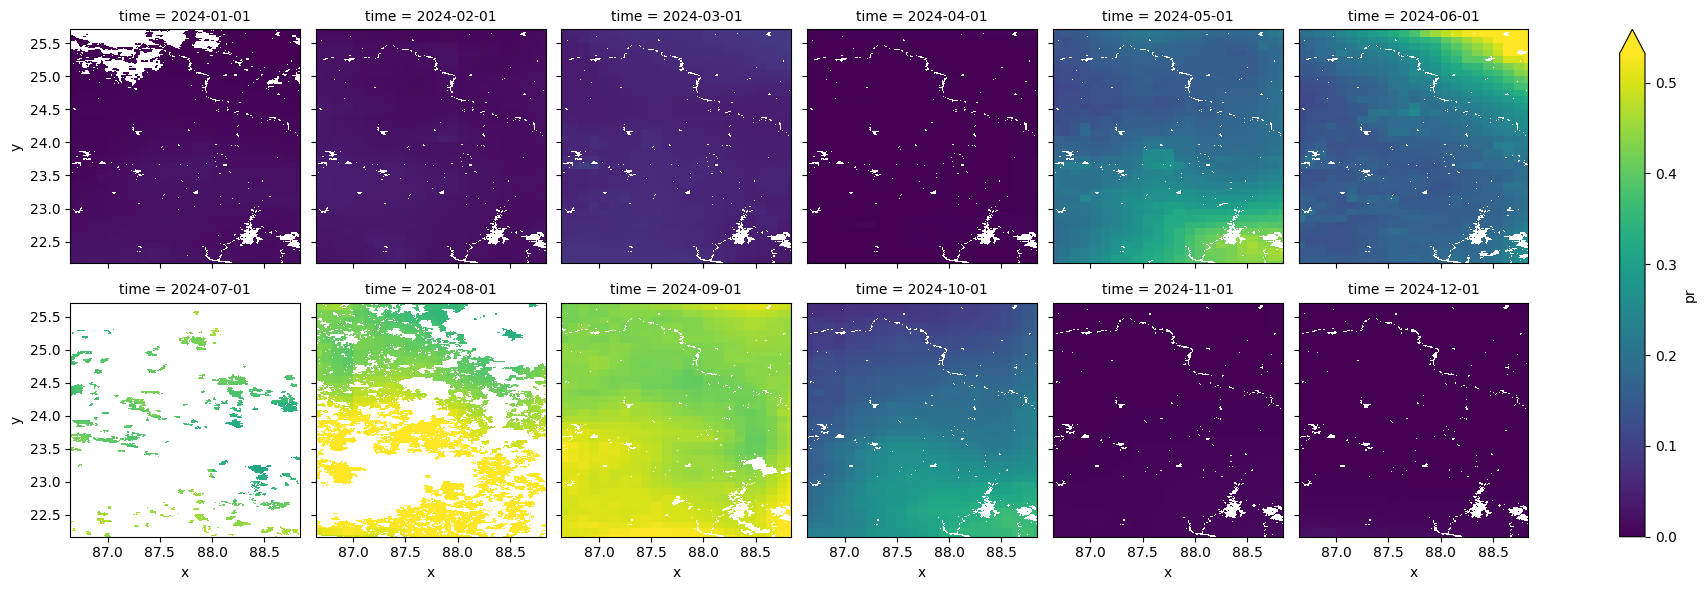

In [144]:
result_sub.pr.plot(
    x='x',y='y',col='time',robust = True, col_wrap = 6
)

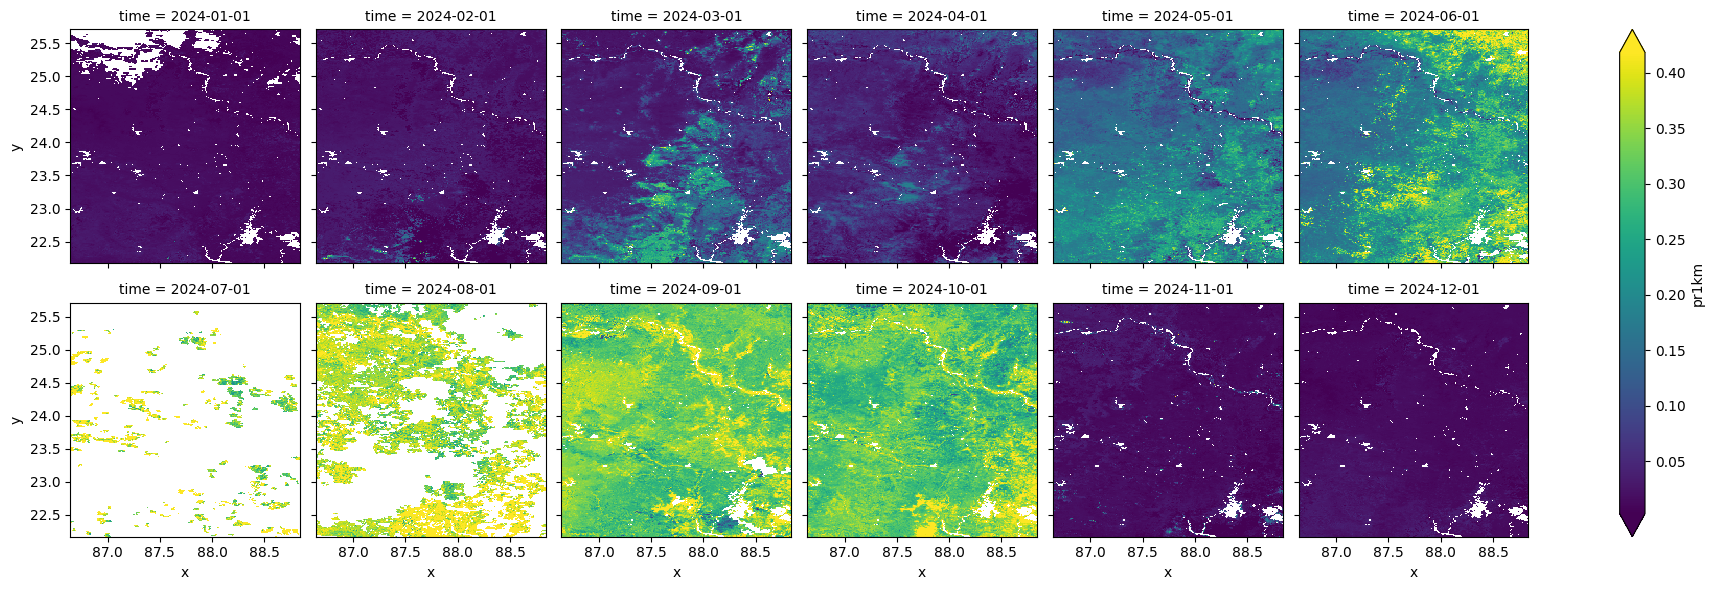

In [145]:
result_sub.pr1km.plot(
    x='x',y='y',col='time',robust = True, col_wrap = 6
)

In [146]:
from google.colab import files

ds1km.to_csv('ds1km_data.csv', index=False)
files.download('ds1km_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>